# Preprocessing, Segmentation & Tokenization

This notebook implements the full data pipeline from raw filtered transactions
to tokenized account sequences ready for embedding models.

**Inputs**:
- `data/processed/paysim_filtered.parquet` — TRANSFER + CASH_OUT transactions only

**Outputs**:
- `data/processed/receiver_accounts.parquet` — account-level features
- `data/processed/train_accounts.parquet`, `val_accounts.parquet`, `test_accounts.parquet`
- `data/processed/train_tokenized.parquet`, `val_tokenized.parquet`, `test_tokenized.parquet`
- `data/configs/split_config.json`
- `data/configs/segmentation_config.json`
- `data/configs/tokenizer_config.json`

---
**Pipeline stages**:
1. Build receiver account dataset
2. Temporal train/val/test split
3. Account behavioral segmentation
4. Fit tokenizer on training data
5. Tokenize all three splits

In [1]:
import sys
from pathlib import Path

# Add project root to path
PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT))

import json
import logging
import warnings

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
import pandas as pd

from src.data.preprocess import (
    build_receiver_dataset,
    temporal_split,
    assign_split_labels,
    save_split_stats,
)
from src.data.segmentation import (
    fit_segmentation,
    assign_segments,
    save_segmentation_config,
)
from src.data.tokenizer import (
    fit_tokenizer,
    tokenize_dataset,
    save_tokenizer_config,
    VOCAB,
)

# Configured logging so we see progress messages
logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s [%(name)s] %(levelname)s: %(message)s',
    datefmt='%H:%M:%S',
)
warnings.filterwarnings('ignore')

plt.rcParams.update({'figure.dpi': 120, 'font.size': 10})

EDA_PATH           = PROJECT_ROOT / 'data' / 'processed' / 'eda'           # figures, CSVs, JSONs
PREPROCESSING_PATH = PROJECT_ROOT / 'data' / 'processed' / 'preprocessing'  # parquets
CONFIGS            = PROJECT_ROOT / 'data' / 'configs'

EDA_PATH.mkdir(parents=True, exist_ok=True)
PREPROCESSING_PATH.mkdir(parents=True, exist_ok=True)
CONFIGS.mkdir(parents=True, exist_ok=True)

print(f'Project root      : {PROJECT_ROOT}')
print(f'EDA output        : {EDA_PATH}')
print(f'Preprocessing out : {PREPROCESSING_PATH}')
print(f'Configs dir       : {CONFIGS}')

Project root      : E:\Study\semester4\mlops\project\fraud-detection-mlops
EDA output        : E:\Study\semester4\mlops\project\fraud-detection-mlops\data\processed\eda
Preprocessing out : E:\Study\semester4\mlops\project\fraud-detection-mlops\data\processed\preprocessing
Configs dir       : E:\Study\semester4\mlops\project\fraud-detection-mlops\data\configs


---
## 2.1 Load Data

In [2]:
filtered_path = PREPROCESSING_PATH / 'paysim_filtered.parquet'
assert filtered_path.exists(), (
    f'Phase 1 output not found at {filtered_path}. '
    'Run notebooks/01_eda.ipynb first.'
)

df = pd.read_parquet(filtered_path)
print(f'Loaded {len(df):,} filtered transactions')
print(f'Columns: {list(df.columns)}')
print(f'Transaction types: {df["type"].value_counts().to_dict()}')
print(f'Fraud transactions: {df["isFraud"].sum():,} ({100*df["isFraud"].mean():.4f}%)')
df.head(3)

Loaded 2,770,409 filtered transactions
Columns: ['step', 'type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig', 'nameDest', 'oldbalanceDest', 'newbalanceDest', 'isFraud', 'isFlaggedFraud']
Transaction types: {'CASH_OUT': 2237500, 'TRANSFER': 532909}
Fraud transactions: 8,213 (0.2965%)


,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,TRANSFER,181.00,C1305486145,181.0,0.0,C553264065,0.0,0.00,1,0
1,1,CASH_OUT,181.00,C840083671,181.0,0.0,C38997010,21182.0,0.00,1,0
2,1,CASH_OUT,229133.94,C905080434,15325.0,0.0,C476402209,5083.0,51513.44,0,0


---
## 2.2 Building Receiver Account Dataset

Aggregate transaction-level data into one row per `nameDest` account.

In [3]:
accounts = build_receiver_dataset(df)

print(f'\nReceiver account dataset shape: {accounts.shape}')
print(f'Fraud receivers: {accounts["is_fraud_receiver"].sum():,}')
print(f'Fraud receiver rate: {100*accounts["is_fraud_receiver"].mean():.4f}%')
print()
accounts.head()

12:17:30 [src.data.preprocess] INFO: Building receiver account dataset from 2770409 transactions...
12:17:32 [src.data.preprocess] INFO: Receiver dataset: 509565 accounts, 8169 fraud receivers (1.6031%)



Receiver account dataset shape: (509565, 6)
Fraud receivers: 8,169
Fraud receiver rate: 1.6031%



,total_volume,txn_count,first_step,last_step,is_fraud_receiver,active_duration
account_id,,,,,,
C1000004082,1923026.06,3,354,374,0,20
C1000004940,1878167.59,10,131,377,0,246
C1000013769,5709273.96,9,177,694,0,517
C100001587,958144.01,5,138,307,0,169
C1000015936,1330515.72,8,18,324,0,306


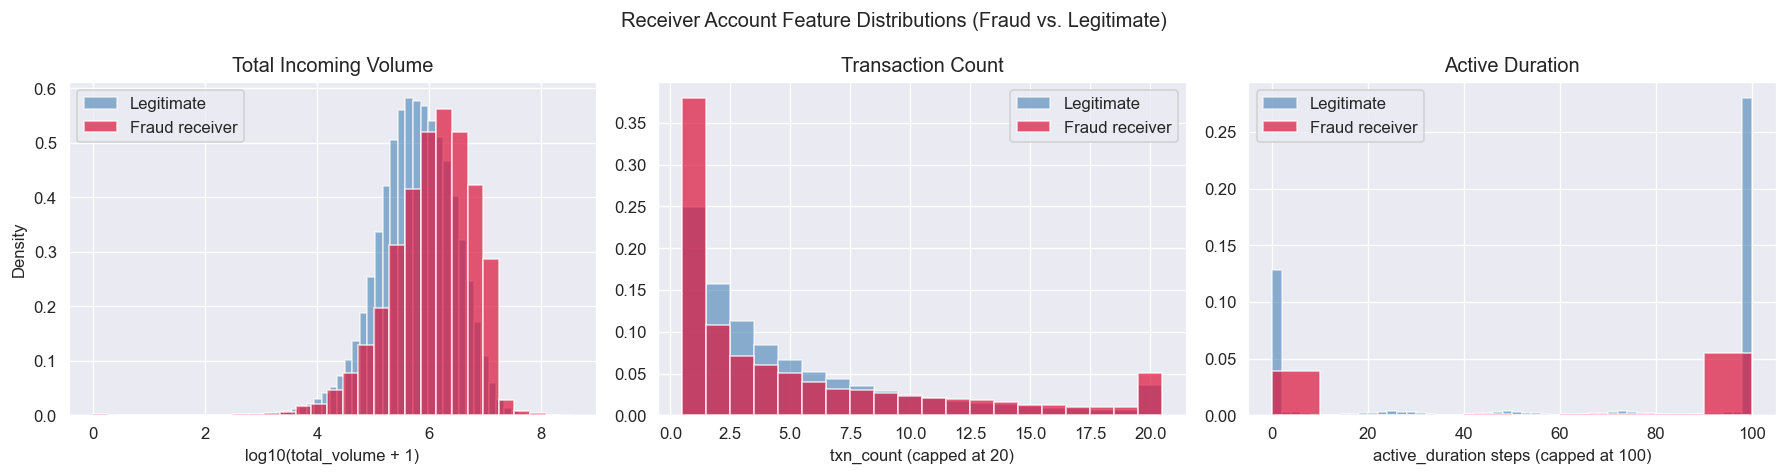

Saved fig_08_account_features.png


In [4]:
# ── Visualizing account feature distributions split by fraud label

fraud_accts  = accounts[accounts['is_fraud_receiver'] == 1]
legit_accts  = accounts[accounts['is_fraud_receiver'] == 0]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Receiver Account Feature Distributions (Fraud vs. Legitimate)', fontsize=12)

# Total volume
axes[0].hist(np.log10(legit_accts['total_volume'] + 1), bins=60,
             alpha=0.6, color='steelblue', label='Legitimate', density=True)
axes[0].hist(np.log10(fraud_accts['total_volume'] + 1), bins=30,
             alpha=0.7, color='crimson', label='Fraud receiver', density=True)
axes[0].set_xlabel('log10(total_volume + 1)')
axes[0].set_ylabel('Density')
axes[0].set_title('Total Incoming Volume')
axes[0].legend()

# Transaction count
max_count = min(20, int(accounts['txn_count'].max()))
bins = np.arange(0.5, max_count + 1.5)
axes[1].hist(legit_accts['txn_count'].clip(upper=max_count), bins=bins,
             alpha=0.6, color='steelblue', label='Legitimate', density=True)
axes[1].hist(fraud_accts['txn_count'].clip(upper=max_count), bins=bins,
             alpha=0.7, color='crimson', label='Fraud receiver', density=True)
axes[1].set_xlabel('txn_count (capped at 20)')
axes[1].set_title('Transaction Count')
axes[1].legend()

# Active duration
max_dur = min(100, int(accounts['active_duration'].max()))
axes[2].hist(legit_accts['active_duration'].clip(upper=max_dur), bins=50,
             alpha=0.6, color='steelblue', label='Legitimate', density=True)
axes[2].hist(fraud_accts['active_duration'].clip(upper=max_dur), bins=10,
             alpha=0.7, color='crimson', label='Fraud receiver', density=True)
axes[2].set_xlabel('active_duration steps (capped at 100)')
axes[2].set_title('Active Duration')
axes[2].legend()

plt.tight_layout()
plt.savefig(EDA_PATH / 'fig_08_account_features.png', bbox_inches='tight')
plt.show()
print('Saved fig_08_account_features.png')

---
## 2.3 Temporal Train / Val / Test Split

Accounts are sorted by `last_step` and partitioned 70 / 15 / 15.

**Why temporal?** The EDA showed fraud rate is NOT constant over time —
it rises in later steps as legitimate volume drops. Random splitting would
cause the model to see future fraud patterns during training.

In [5]:
train_accts, val_accts, test_accts = temporal_split(
    accounts, train_ratio=0.70, val_ratio=0.15
)

print('Account counts per split:')
print(f'  Train : {len(train_accts):>8,}  '
      f'({100*len(train_accts)/len(accounts):.1f}%)')
print(f'  Val   : {len(val_accts):>8,}  '
      f'({100*len(val_accts)/len(accounts):.1f}%)')
print(f'  Test  : {len(test_accts):>8,}  '
      f'({100*len(test_accts)/len(accounts):.1f}%)')
print()
print('Fraud receiver rate per split:')
for name, split in [('Train', train_accts), ('Val', val_accts), ('Test', test_accts)]:
    rate = 100 * split['is_fraud_receiver'].mean()
    count = int(split['is_fraud_receiver'].sum())
    print(f'  {name:5}: {count:>5,} fraud receivers ({rate:.4f}%)')

12:17:33 [src.data.preprocess] INFO: Temporal split — train: 356695 accounts (last_step ≤ 404), val: 76434 accounts (last_step ≤ 552), test: 76436 accounts
12:17:33 [src.data.preprocess] INFO: Fraud receivers per split — train: 3384, val: 2022, test: 2763


Account counts per split:
  Train :  356,695  (70.0%)
  Val   :   76,434  (15.0%)
  Test  :   76,436  (15.0%)

Fraud receiver rate per split:
  Train: 3,384 fraud receivers (0.9487%)
  Val  : 2,022 fraud receivers (2.6454%)
  Test : 2,763 fraud receivers (3.6148%)


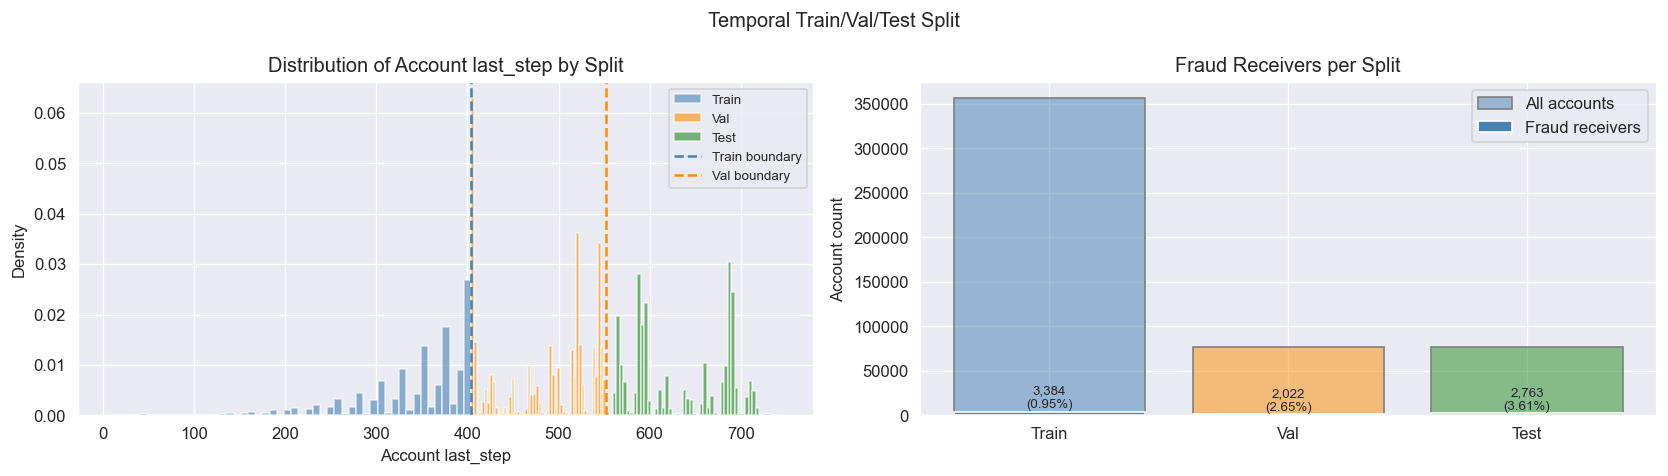

Saved fig_09_temporal_split.png


In [6]:
# ── Visualizing the temporal split boundary

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
fig.suptitle('Temporal Train/Val/Test Split', fontsize=12)

# Account last_step distributions
for name, split, color in [
    ('Train', train_accts, 'steelblue'),
    ('Val',   val_accts,   'darkorange'),
    ('Test',  test_accts,  'forestgreen'),
]:
    axes[0].hist(split['last_step'], bins=50, alpha=0.6, color=color, label=name, density=True)

axes[0].axvline(int(train_accts['last_step'].max()), color='steelblue',
                linestyle='--', linewidth=1.5, label=f'Train boundary')
axes[0].axvline(int(val_accts['last_step'].max()), color='darkorange',
                linestyle='--', linewidth=1.5, label=f'Val boundary')
axes[0].set_xlabel('Account last_step')
axes[0].set_ylabel('Density')
axes[0].set_title('Distribution of Account last_step by Split')
axes[0].legend(fontsize=8)

# Fraud receiver counts
split_names  = ['Train', 'Val', 'Test']
fraud_counts = [
    int(train_accts['is_fraud_receiver'].sum()),
    int(val_accts['is_fraud_receiver'].sum()),
    int(test_accts['is_fraud_receiver'].sum()),
]
total_counts = [len(train_accts), len(val_accts), len(test_accts)]
colors = ['steelblue', 'darkorange', 'forestgreen']
bars = axes[1].bar(split_names, total_counts, color=[c + '80' for c in ['#4682b4', '#ff8c00', '#228b22']],
                   label='All accounts', edgecolor='gray')
bars2 = axes[1].bar(split_names, fraud_counts, color=colors, label='Fraud receivers')
for bar, fc, tc in zip(bars2, fraud_counts, total_counts):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + tc * 0.005,
                 f'{fc:,}\n({100*fc/tc:.2f}%)', ha='center', va='bottom', fontsize=8)
axes[1].set_ylabel('Account count')
axes[1].set_title('Fraud Receivers per Split')
axes[1].legend()

plt.tight_layout()
plt.savefig(EDA_PATH / 'fig_09_temporal_split.png', bbox_inches='tight')
plt.show()
print('Saved fig_09_temporal_split.png')

In [24]:
# Assign split labels to each transaction and verify
df_split = assign_split_labels(df, train_accts, val_accts, test_accts)

print('Transaction-level split validation:')
print(df_split.groupby('split')['isFraud'].agg(['count', 'sum', 'mean']).rename(
    columns={'count': 'n_transactions', 'sum': 'n_fraud', 'mean': 'fraud_rate'}
))

# Assertions
total_fraud = df_split['isFraud'].sum()
assert total_fraud == df['isFraud'].sum(), 'Fraud count changed after split labeling!'
assert set(df_split['split'].unique()) == {'train', 'val', 'test'}, 'Unexpected split labels'
assert df_split['split'].isna().sum() == 0, 'NaN split labels found'
print(f'\nAll assertions passed. Total fraud preserved: {total_fraud:,}')
print(df_split.head())

12:23:45 [src.data.preprocess] INFO: Split 'train': 1835406 transactions, 3401 fraud (0.1853%)
12:23:45 [src.data.preprocess] INFO: Split 'val': 475579 transactions, 2031 fraud (0.4271%)
12:23:45 [src.data.preprocess] INFO: Split 'test': 459424 transactions, 2781 fraud (0.6053%)


Transaction-level split validation:
       n_transactions  n_fraud  fraud_rate
split                                     
test           459424     2781    0.006053
train         1835406     3401    0.001853
val            475579     2031    0.004271

All assertions passed. Total fraud preserved: 8,213
   step      type     amount     nameOrig  oldbalanceOrg  newbalanceOrig  \
0     1  TRANSFER     181.00  C1305486145          181.0             0.0   
1     1  CASH_OUT     181.00   C840083671          181.0             0.0   
2     1  CASH_OUT  229133.94   C905080434        15325.0             0.0   
3     1  TRANSFER  215310.30  C1670993182          705.0             0.0   
4     1  TRANSFER  311685.89  C1984094095        10835.0             0.0   

      nameDest  oldbalanceDest  newbalanceDest  isFraud  isFlaggedFraud  split  
0   C553264065             0.0            0.00        1               0  train  
1    C38997010         21182.0            0.00        1               0    va

---
## 3.1 Account Behavioral Segmentation

Assign `SEG_MICRO`, `SEG_REGULAR`, or `SEG_HEAVY` to each receiver account
based on a composite activity score of total_volume, txn_count, and active_duration.

**Critical**: Thresholds are fit ONLY on training accounts and applied to val/test
using training-set normalization.

**Expected**: Most fraud receivers → `SEG_MICRO` (single-use, small amounts).

In [8]:
seg_thresholds = fit_segmentation(
    train_accts,
    quantile_boundaries=[0.33, 0.75]
)

print('Segmentation thresholds (fit on training set only):')
print(f'  SEG_MICRO   ≤ {seg_thresholds["score_thresholds"][0]:.4f}')
print(f'  SEG_REGULAR ≤ {seg_thresholds["score_thresholds"][1]:.4f}')
print(f'  SEG_HEAVY   >  {seg_thresholds["score_thresholds"][1]:.4f}')
print()
print('Feature stats from training set (used for normalization):')
for feat, stats in seg_thresholds['feature_stats'].items():
    print(f'  {feat}: min={stats["min"]:.2f}, max={stats["max"]:.2f}')

12:17:36 [src.data.segmentation] INFO: Segmentation thresholds: SEG_MICRO ≤ 0.0768 < SEG_REGULAR ≤ 0.5893 < SEG_HEAVY
12:17:36 [src.data.segmentation] INFO: Training distribution: SEG_MICRO=117710 (33.0%), SEG_REGULAR=149811 (42.0%), SEG_HEAVY=89174 (25.0%)


Segmentation thresholds (fit on training set only):
  SEG_MICRO   ≤ 0.0768
  SEG_REGULAR ≤ 0.5893
  SEG_HEAVY   >  0.5893

Feature stats from training set (used for normalization):
  total_volume: min=1.74, max=273927022.99
  txn_count: min=1.00, max=75.00
  active_duration: min=0.00, max=402.00


In [26]:
seg_thresholds

{'score_thresholds': [0.07684102212648437, 0.5892875244395859],
 'feature_stats': {'total_volume': {'min': 1.74, 'max': 273927022.99},
  'txn_count': {'min': 1.0, 'max': 75.0},
  'active_duration': {'min': 0.0, 'max': 402.0}},
 'segment_names': ['SEG_MICRO', 'SEG_REGULAR', 'SEG_HEAVY'],
 'quantile_boundaries': [0.33, 0.75]}

In [9]:
# Assign segments to all three splits
train_segments = assign_segments(train_accts, seg_thresholds)
val_segments   = assign_segments(val_accts,   seg_thresholds)
test_segments  = assign_segments(test_accts,  seg_thresholds)

# Combine for analysis
all_segments = pd.concat([train_segments, val_segments, test_segments])
accounts_with_seg = accounts.copy()
accounts_with_seg['segment'] = all_segments

print('Segment distribution across all accounts:')
print(all_segments.value_counts().to_frame('count').assign(
    pct=lambda x: (100 * x['count'] / len(all_segments)).round(2)
))

12:17:36 [src.data.segmentation] INFO: Segment distribution: {'SEG_REGULAR': 149811, 'SEG_MICRO': 117710, 'SEG_HEAVY': 89174}
12:17:36 [src.data.segmentation] INFO: Segment distribution: {'SEG_HEAVY': 38105, 'SEG_REGULAR': 21460, 'SEG_MICRO': 16869}
12:17:36 [src.data.segmentation] INFO: Segment distribution: {'SEG_HEAVY': 53424, 'SEG_MICRO': 17376, 'SEG_REGULAR': 5636}


Segment distribution across all accounts:
              count    pct
SEG_HEAVY    180703  35.46
SEG_REGULAR  176907  34.72
SEG_MICRO    151955  29.82


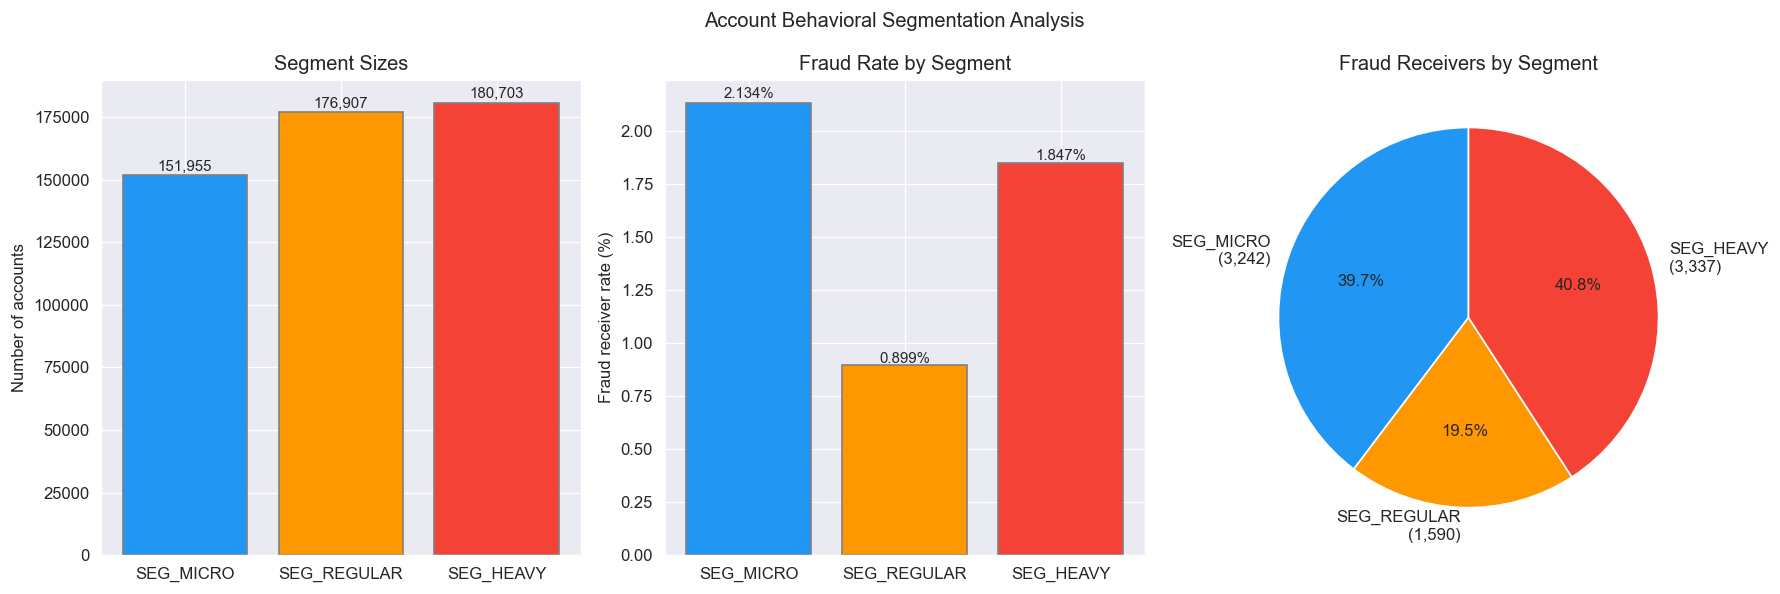

Saved fig_10_segmentation.png


In [10]:
# ── Segment analysis visualization ────────────────────────────────────────────

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Account Behavioral Segmentation Analysis', fontsize=12)

seg_order  = ['SEG_MICRO', 'SEG_REGULAR', 'SEG_HEAVY']
seg_colors = ['#2196F3', '#FF9800', '#F44336']

# 1. Segment size
counts = [int((all_segments == s).sum()) for s in seg_order]
bars = axes[0].bar(seg_order, counts, color=seg_colors, edgecolor='gray')
for bar, count in zip(bars, counts):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() * 1.01,
                 f'{count:,}', ha='center', fontsize=9)
axes[0].set_ylabel('Number of accounts')
axes[0].set_title('Segment Sizes')

# 2. Fraud receiver rate per segment
fraud_rates = [
    100 * accounts_with_seg[accounts_with_seg['segment'] == s]['is_fraud_receiver'].mean()
    for s in seg_order
]
bars = axes[1].bar(seg_order, fraud_rates, color=seg_colors, edgecolor='gray')
for bar, rate in zip(bars, fraud_rates):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() * 1.01,
                 f'{rate:.3f}%', ha='center', fontsize=9)
axes[1].set_ylabel('Fraud receiver rate (%)')
axes[1].set_title('Fraud Rate by Segment')

# 3. Fraud receiver distribution across segments
fraud_counts = [
    int(accounts_with_seg[
        (accounts_with_seg['segment'] == s) &
        (accounts_with_seg['is_fraud_receiver'] == 1)
    ].shape[0])
    for s in seg_order
]
axes[2].pie(
    fraud_counts,
    labels=[f'{s}\n({c:,})' for s, c in zip(seg_order, fraud_counts)],
    colors=seg_colors,
    autopct='%1.1f%%',
    startangle=90,
)
axes[2].set_title('Fraud Receivers by Segment')

plt.tight_layout()
plt.savefig(EDA_PATH / 'fig_10_segmentation.png', bbox_inches='tight')
plt.show()
print('Saved fig_10_segmentation.png')

In [11]:
# Sanity check: fraud receivers should be heavily concentrated in SEG_MICRO
micro_fraud_rate  = float(accounts_with_seg[accounts_with_seg['segment'] == 'SEG_MICRO']['is_fraud_receiver'].mean())
heavy_fraud_rate  = float(accounts_with_seg[accounts_with_seg['segment'] == 'SEG_HEAVY']['is_fraud_receiver'].mean())

print(f'SEG_MICRO fraud rate  : {100*micro_fraud_rate:.4f}%')
print(f'SEG_HEAVY fraud rate  : {100*heavy_fraud_rate:.4f}%')
print()
# EDA established fraud receivers are single-use → SEG_MICRO > SEG_HEAVY expected
if micro_fraud_rate > heavy_fraud_rate:
    print('✓ As expected from EDA: fraud rate is higher in SEG_MICRO (single-use accounts)')
else:
    print('⚠ Unexpected: SEG_HEAVY has higher fraud rate — review segmentation')

SEG_MICRO fraud rate  : 2.1335%
SEG_HEAVY fraud rate  : 1.8467%

✓ As expected from EDA: fraud rate is higher in SEG_MICRO (single-use accounts)


---
## 3.2 Fit Tokenizer on Training Data

Compute amount and frequency quantile thresholds from training transactions only.
These thresholds are used to discretize continuous features into tokens.

**Amount bins** (5 levels via 4 quantiles): AMT_VERY_LOW → AMT_VERY_HIGH  
**Frequency bins** (3 levels via 2 quantiles): FREQ_LOW → FREQ_HIGH

EDA finding: Fraud is heavily concentrated in the top amount quantiles,
so the AMT_HIGH / AMT_VERY_HIGH tokens should be strongly discriminative.

In [12]:
train_df = df_split[df_split['split'] == 'train'].copy()

print(f'Training transactions: {len(train_df):,}')
print(f'Amount range: [{train_df["amount"].min():.2f}, {train_df["amount"].max():.2f}]')
print(f'Amount mean : {train_df["amount"].mean():.2f}')
print(f'Amount median: {train_df["amount"].median():.2f}')

Training transactions: 1,835,406
Amount range: [0.00, 73823490.36]
Amount mean : 307360.57
Amount median: 167452.28


In [13]:
tok_thresholds = fit_tokenizer(
    train_df,
    amount_quantiles=[0.20, 0.50, 0.80, 0.95],
    frequency_quantiles=[0.25, 0.75],
    freq_lookback_steps=24,
)

print('Amount thresholds (training set):')
qs = tok_thresholds['amount_quantiles']
ts = tok_thresholds['amount_thresholds']
bins = ['AMT_VERY_LOW', 'AMT_LOW', 'AMT_MEDIUM', 'AMT_HIGH', 'AMT_VERY_HIGH']
print(f'  {bins[0]}: amount < {ts[0]:,.2f}  (< q{int(100*qs[0])})')
for i in range(1, 4):
    print(f'  {bins[i]}: {ts[i-1]:,.2f} ≤ amount < {ts[i]:,.2f}  (q{int(100*qs[i-1])}–q{int(100*qs[i])})')
print(f'  {bins[4]}: amount ≥ {ts[3]:,.2f}  (≥ q{int(100*qs[3])})')
print()
print('Frequency thresholds (training set):')
fqs = tok_thresholds['frequency_quantiles']
fts = tok_thresholds['freq_thresholds']
print(f'  FREQ_LOW   : recent_count ≤ {fts[0]:.1f}  (≤ q{int(100*fqs[0])})')
print(f'  FREQ_MEDIUM: {fts[0]:.1f} < recent_count ≤ {fts[1]:.1f}  (q{int(100*fqs[0])}–q{int(100*fqs[1])})')
print(f'  FREQ_HIGH  : recent_count > {fts[1]:.1f}  (> q{int(100*fqs[1])})')

12:17:38 [src.data.tokenizer] INFO: Amount thresholds [0.2, 0.5, 0.8, 0.95]: [64767.5, 167452.28, 345300.24, 910786.5225]
12:17:38 [src.data.tokenizer] INFO: Computing recent frequency counts (lookback=24 steps) on 1835406 training txns...
12:17:58 [src.data.tokenizer] INFO: Frequency thresholds [0.25, 0.75]: [0.0, 1.0]


Amount thresholds (training set):
  AMT_VERY_LOW: amount < 64,767.50  (< q20)
  AMT_LOW: 64,767.50 ≤ amount < 167,452.28  (q20–q50)
  AMT_MEDIUM: 167,452.28 ≤ amount < 345,300.24  (q50–q80)
  AMT_HIGH: 345,300.24 ≤ amount < 910,786.52  (q80–q95)
  AMT_VERY_HIGH: amount ≥ 910,786.52  (≥ q95)

Frequency thresholds (training set):
  FREQ_LOW   : recent_count ≤ 0.0  (≤ q25)
  FREQ_MEDIUM: 0.0 < recent_count ≤ 1.0  (q25–q75)
  FREQ_HIGH  : recent_count > 1.0  (> q75)


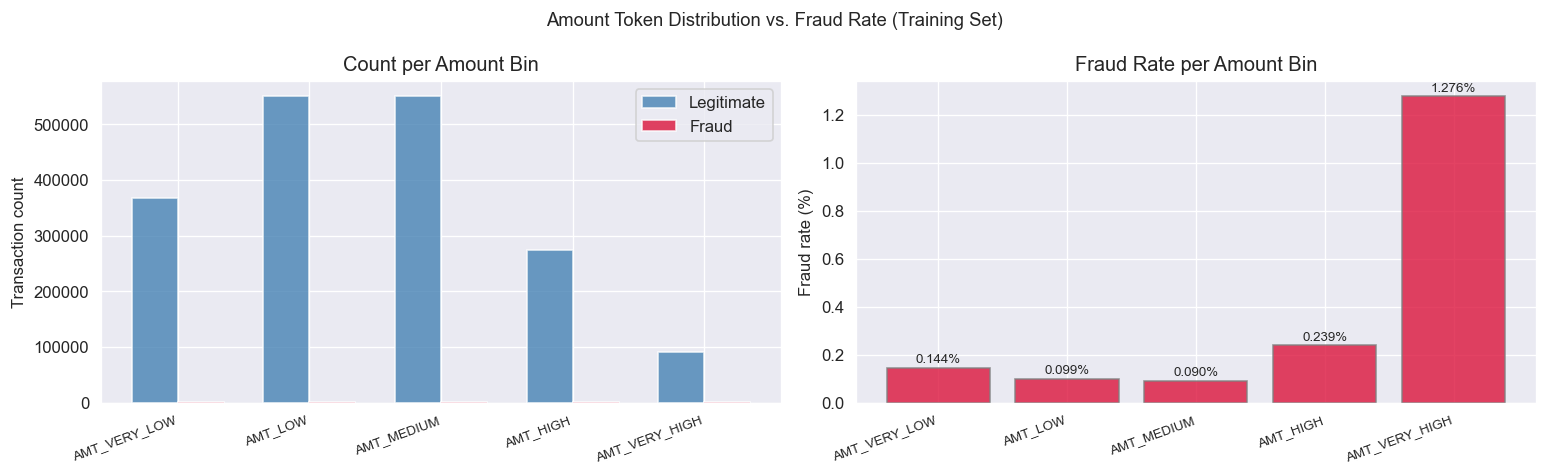

Saved fig_11_amount_tokens.png


In [14]:
# ── Visualize amount bin distributions (fraud vs. legit) ──────────────────────

from src.data.tokenizer import _get_amount_token

train_df['amt_token'] = train_df['amount'].apply(
    lambda a: _get_amount_token(a, tok_thresholds)
)

amt_token_order = ['AMT_VERY_LOW', 'AMT_LOW', 'AMT_MEDIUM', 'AMT_HIGH', 'AMT_VERY_HIGH']
fraud_by_token  = train_df[train_df['isFraud']==1].groupby('amt_token').size().reindex(amt_token_order, fill_value=0)
legit_by_token  = train_df[train_df['isFraud']==0].groupby('amt_token').size().reindex(amt_token_order, fill_value=0)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle('Amount Token Distribution vs. Fraud Rate (Training Set)', fontsize=11)

x = np.arange(len(amt_token_order))
w = 0.35
axes[0].bar(x - w/2, legit_by_token.values,  width=w, label='Legitimate', color='steelblue', alpha=0.8)
axes[0].bar(x + w/2, fraud_by_token.values,  width=w, label='Fraud', color='crimson', alpha=0.8)
axes[0].set_xticks(x)
axes[0].set_xticklabels(amt_token_order, rotation=20, ha='right', fontsize=8)
axes[0].set_ylabel('Transaction count')
axes[0].set_title('Count per Amount Bin')
axes[0].legend()

total_by_token = fraud_by_token + legit_by_token
fraud_rate_by_token = 100 * fraud_by_token / total_by_token
axes[1].bar(amt_token_order, fraud_rate_by_token.values, color='crimson', alpha=0.8, edgecolor='gray')
for i, (tok, rate) in enumerate(zip(amt_token_order, fraud_rate_by_token)):
    axes[1].text(i, rate + 0.02, f'{rate:.3f}%', ha='center', fontsize=8)
axes[1].set_ylabel('Fraud rate (%)')
axes[1].set_title('Fraud Rate per Amount Bin')
axes[1].set_xticks(range(len(amt_token_order)))
axes[1].set_xticklabels(amt_token_order, rotation=20, ha='right', fontsize=8)

plt.tight_layout()
plt.savefig(EDA_PATH / 'fig_11_amount_tokens.png', bbox_inches='tight')
plt.show()
print('Saved fig_11_amount_tokens.png')

---
## 3.3 Tokenize All Three Splits

Build the full token sequence for every receiver account in each split.

Token sequence format per account:
```
[CLS] [ACCT] SEG_MICRO [TXN] TRANSFER AMT_VERY_HIGH TIME_MORNING DAY_WEEKDAY FREQ_LOW BAL_EXACT_DEBIT BAL_UNKNOWN [SEP]
```

**Note**: This step can take several minutes for large splits (2.7M+ accounts).

In [15]:
# Prepare account label series
account_labels = accounts['is_fraud_receiver']

# Tokenize training split
print('Tokenizing training split...')
train_tok = tokenize_dataset(
    df_split[df_split['split'] == 'train'],
    train_segments,
    tok_thresholds,
    account_labels,
    max_transactions=30,
    freq_lookback_steps=24,
)
print(f'Training tokenized: {len(train_tok):,} accounts')

Tokenizing training split...


12:18:06 [src.data.tokenizer] INFO: Tokenizing account 0 / 356695 ...
12:18:39 [src.data.tokenizer] INFO: Tokenizing account 50000 / 356695 ...
12:19:07 [src.data.tokenizer] INFO: Tokenizing account 100000 / 356695 ...
12:19:30 [src.data.tokenizer] INFO: Tokenizing account 150000 / 356695 ...
12:19:53 [src.data.tokenizer] INFO: Tokenizing account 200000 / 356695 ...
12:20:16 [src.data.tokenizer] INFO: Tokenizing account 250000 / 356695 ...
12:20:40 [src.data.tokenizer] INFO: Tokenizing account 300000 / 356695 ...
12:21:08 [src.data.tokenizer] INFO: Tokenizing account 350000 / 356695 ...
12:21:12 [src.data.tokenizer] INFO: Tokenized 356695 accounts (3384 fraud, 0.9487%)


Training tokenized: 356,695 accounts


In [16]:
print('Tokenizing validation split...')
val_tok = tokenize_dataset(
    df_split[df_split['split'] == 'val'],
    val_segments,
    tok_thresholds,
    account_labels,
    max_transactions=30,
    freq_lookback_steps=24,
)
print(f'Validation tokenized: {len(val_tok):,} accounts')

Tokenizing validation split...


12:21:14 [src.data.tokenizer] INFO: Tokenizing account 0 / 76434 ...
12:21:46 [src.data.tokenizer] INFO: Tokenizing account 50000 / 76434 ...
12:22:02 [src.data.tokenizer] INFO: Tokenized 76434 accounts (2022 fraud, 2.6454%)


Validation tokenized: 76,434 accounts


In [17]:
print('Tokenizing test split...')
test_tok = tokenize_dataset(
    df_split[df_split['split'] == 'test'],
    test_segments,
    tok_thresholds,
    account_labels,
    max_transactions=30,
    freq_lookback_steps=24,
)
print(f'Test tokenized: {len(test_tok):,} accounts')

Tokenizing test split...


12:22:03 [src.data.tokenizer] INFO: Tokenizing account 0 / 76436 ...
12:22:31 [src.data.tokenizer] INFO: Tokenizing account 50000 / 76436 ...
12:22:44 [src.data.tokenizer] INFO: Tokenized 76436 accounts (2763 fraud, 3.6148%)


Test tokenized: 76,436 accounts


---
## 3.4 Example Token Sequences

In [18]:
print('=== Example: FRAUD receiver account ===')
fraud_sample = train_tok[train_tok['is_fraud_receiver'] == 1].head(3)
for acct_id, row in fraud_sample.iterrows():
    print(f'\nAccount: {acct_id}')
    print(f'Segment : {row["segment"]}')
    print(f'Tokens  : {" ".join(row["token_sequence"])}')

print('\n\n=== Example: LEGITIMATE receiver account ===')
legit_sample = train_tok[train_tok['is_fraud_receiver'] == 0].head(3)
for acct_id, row in legit_sample.iterrows():
    print(f'\nAccount: {acct_id}')
    print(f'Segment : {row["segment"]}')
    print(f'Tokens  : {" ".join(row["token_sequence"])}')

=== Example: FRAUD receiver account ===

Account: C1000039615
Segment : SEG_REGULAR
Tokens  : [CLS] [ACCT] SEG_REGULAR [TXN] TRANSFER AMT_LOW TIME_MORNING DAY_WEEKDAY FREQ_LOW BAL_EXACT_DEBIT BAL_UNKNOWN [TXN] CASH_OUT AMT_LOW TIME_MORNING DAY_WEEKEND FREQ_LOW BAL_UNDER_DEBIT BAL_EXACT_CREDIT [SEP]

Account: C1000855680
Segment : SEG_MICRO
Tokens  : [CLS] [ACCT] SEG_MICRO [TXN] TRANSFER AMT_VERY_HIGH TIME_LATE_NIGHT DAY_WEEKDAY FREQ_LOW BAL_EXACT_DEBIT BAL_UNKNOWN [SEP]

Account: C1000868784
Segment : SEG_MICRO
Tokens  : [CLS] [ACCT] SEG_MICRO [TXN] TRANSFER AMT_VERY_HIGH TIME_AFTERNOON DAY_WEEKDAY FREQ_LOW BAL_EXACT_DEBIT BAL_UNKNOWN [SEP]


=== Example: LEGITIMATE receiver account ===

Account: C1000004082
Segment : SEG_REGULAR
Tokens  : [CLS] [ACCT] SEG_REGULAR [TXN] CASH_OUT AMT_MEDIUM TIME_EVENING DAY_WEEKDAY FREQ_LOW BAL_UNDER_DEBIT BAL_EXACT_CREDIT [TXN] TRANSFER AMT_VERY_HIGH TIME_MORNING DAY_WEEKDAY FREQ_MEDIUM BAL_UNDER_DEBIT BAL_EXACT_CREDIT [TXN] CASH_OUT AMT_HIGH TIME_AFTE

Token sequence length statistics (training set):
                      count       mean        std   min   25%   50%   75%  \
is_fraud_receiver                                                           
Legitimate         353311.0  44.815440  43.252442  12.0  12.0  28.0  60.0   
Fraud                3384.0  59.099291  54.140331  12.0  20.0  36.0  84.0   

                     max  
is_fraud_receiver         
Legitimate         244.0  
Fraud              244.0  


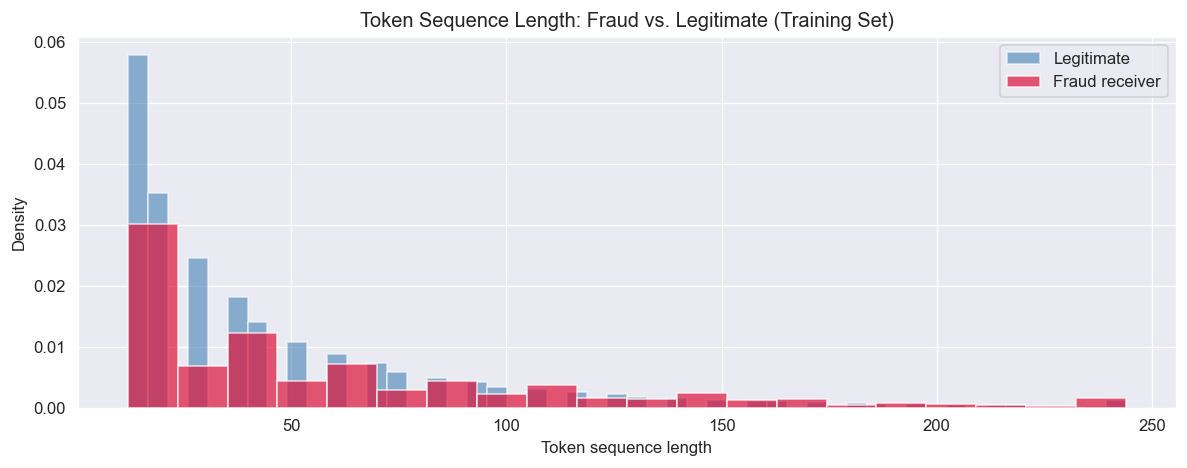

Saved fig_12_sequence_lengths.png


In [19]:
# ── Token sequence length statistics ──────────────────────────────────────────

train_tok['seq_len'] = train_tok['token_sequence'].apply(len)

print('Token sequence length statistics (training set):')
print(train_tok.groupby('is_fraud_receiver')['seq_len'].describe().rename(
    index={0: 'Legitimate', 1: 'Fraud'}
))

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(
    train_tok[train_tok['is_fraud_receiver']==0]['seq_len'],
    bins=50, alpha=0.6, color='steelblue', label='Legitimate', density=True
)
ax.hist(
    train_tok[train_tok['is_fraud_receiver']==1]['seq_len'],
    bins=20, alpha=0.7, color='crimson', label='Fraud receiver', density=True
)
ax.set_xlabel('Token sequence length')
ax.set_ylabel('Density')
ax.set_title('Token Sequence Length: Fraud vs. Legitimate (Training Set)')
ax.legend()
plt.tight_layout()
plt.savefig(EDA_PATH / 'fig_12_sequence_lengths.png', bbox_inches='tight')
plt.show()
print('Saved fig_12_sequence_lengths.png')

In [20]:
# ── Token frequency analysis ───────────────────────────────────────────────────

from collections import Counter

# Count token frequencies in fraud vs. legitimate sequences
fraud_tokens = []
legit_tokens = []
for _, row in train_tok.iterrows():
    toks = [t for t in row['token_sequence'] if not t.startswith('[')]
    if row['is_fraud_receiver'] == 1:
        fraud_tokens.extend(toks)
    else:
        legit_tokens.extend(toks)

fraud_counter = Counter(fraud_tokens)
legit_counter = Counter(legit_tokens)

# Compute relative frequency (lift) for each token
all_toks = set(fraud_counter.keys()) | set(legit_counter.keys())
total_fraud_toks = sum(fraud_counter.values())
total_legit_toks = sum(legit_counter.values())

lifts = []
for tok in all_toks:
    f_rate = fraud_counter.get(tok, 0) / total_fraud_toks
    l_rate = legit_counter.get(tok, 0) / (total_legit_toks + 1)
    lift = f_rate / (l_rate + 1e-10)
    lifts.append({'token': tok, 'fraud_rate': f_rate, 'legit_rate': l_rate, 'lift': lift})

lifts_df = pd.DataFrame(lifts).sort_values('lift', ascending=False)

print('Top 10 tokens most enriched in FRAUD sequences (by lift):')
print(lifts_df[['token', 'fraud_rate', 'legit_rate', 'lift']].head(10).to_string(index=False))

print('\nTop 10 tokens most enriched in LEGITIMATE sequences (lowest lift):')
print(lifts_df[['token', 'fraud_rate', 'legit_rate', 'lift']].tail(10).to_string(index=False))

Top 10 tokens most enriched in FRAUD sequences (by lift):
          token  fraud_rate  legit_rate     lift
TIME_LATE_NIGHT    0.005891    0.001120 5.258070
  BAL_NO_CHANGE    0.000024    0.000007 3.350069
BAL_EXACT_DEBIT    0.031009    0.014112 2.197398
  AMT_VERY_HIGH    0.014315    0.006812 2.101400
       TRANSFER    0.036071    0.025430 1.418448
      FREQ_HIGH    0.038533    0.031021 1.242163
      SEG_HEAVY    0.008311    0.006768 1.227931
       AMT_HIGH    0.024031    0.020753 1.157971
    BAL_UNKNOWN    0.073187    0.064920 1.127335
   TIME_MORNING    0.028775    0.026079 1.103382

Top 10 tokens most enriched in LEGITIMATE sequences (lowest lift):
           token  fraud_rate  legit_rate     lift
    TIME_EVENING    0.045805    0.049392 0.927366
        CASH_OUT    0.103883    0.113536 0.914980
        FREQ_LOW    0.065723    0.072179 0.910550
BAL_EXACT_CREDIT    0.113935    0.125224 0.909852
    AMT_VERY_LOW    0.024908    0.027880 0.893408
         AMT_LOW    0.036779    0.0

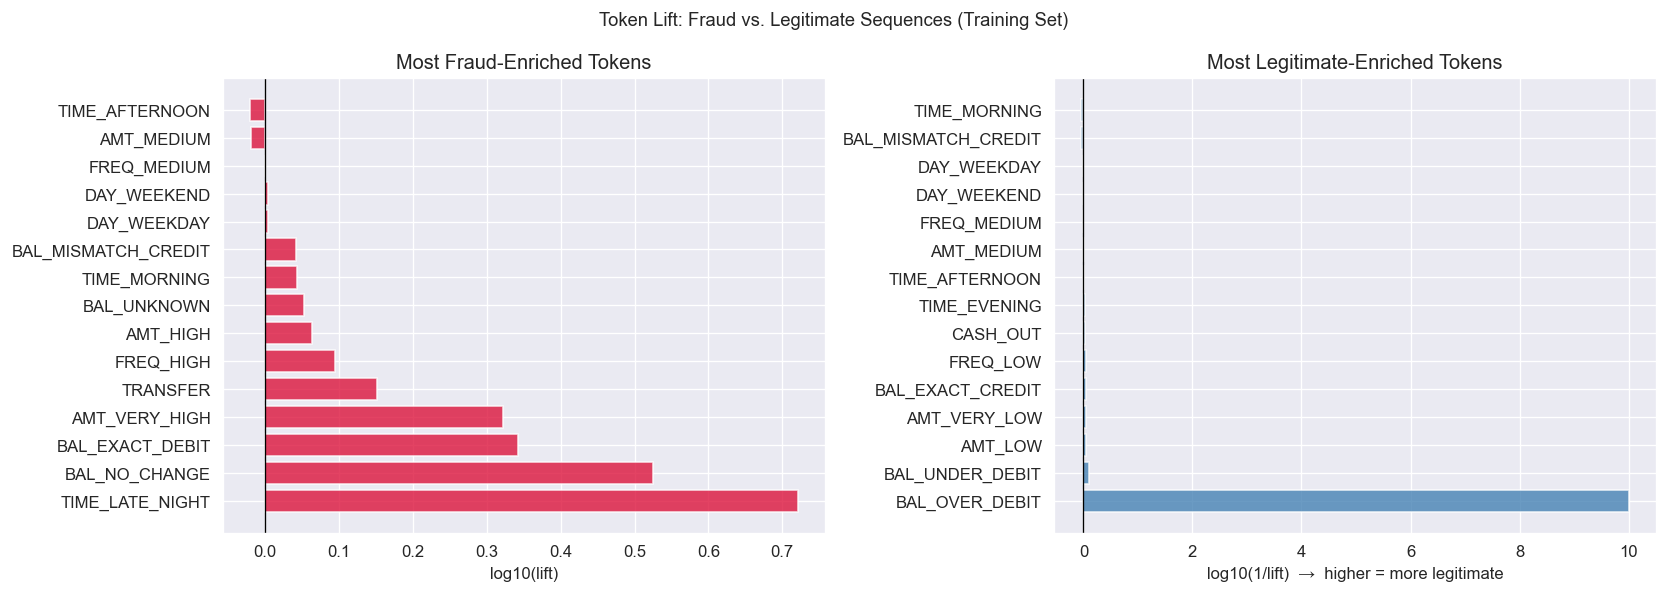

Saved fig_13_token_lift.png


In [21]:
# ── Visualize token lift ───────────────────────────────────────────────────────

# Focus on semantically meaningful tokens (not SEG_ or structural tokens)
meaningful_toks = lifts_df[
    ~lifts_df['token'].str.startswith('SEG_') &
    ~lifts_df['token'].str.startswith('[') &
    (lifts_df['token'] != 'RECEIVER') &
    (lifts_df['token'] != 'SENDER')
].copy()

top15_fraud = meaningful_toks.head(15)
top15_legit = meaningful_toks.tail(15).iloc[::-1]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Token Lift: Fraud vs. Legitimate Sequences (Training Set)', fontsize=11)

axes[0].barh(top15_fraud['token'], np.log10(top15_fraud['lift']), color='crimson', alpha=0.8)
axes[0].set_xlabel('log10(lift)')
axes[0].set_title('Most Fraud-Enriched Tokens')
axes[0].axvline(0, color='black', linewidth=0.8)

axes[1].barh(top15_legit['token'], np.log10(1 / (top15_legit['lift'] + 1e-10)), color='steelblue', alpha=0.8)
axes[1].set_xlabel('log10(1/lift)  →  higher = more legitimate')
axes[1].set_title('Most Legitimate-Enriched Tokens')
axes[1].axvline(0, color='black', linewidth=0.8)

plt.tight_layout()
plt.savefig(EDA_PATH / 'fig_13_token_lift.png', bbox_inches='tight')
plt.show()
print('Saved fig_13_token_lift.png')

---
## 3.5 Save All Outputs

In [22]:
# ── Account-level datasets → preprocessing/ ───────────────────────────────────
accounts.to_parquet(PREPROCESSING_PATH / 'receiver_accounts.parquet')
train_accts.to_parquet(PREPROCESSING_PATH / 'train_accounts.parquet')
val_accts.to_parquet(PREPROCESSING_PATH  / 'val_accounts.parquet')
test_accts.to_parquet(PREPROCESSING_PATH / 'test_accounts.parquet')
print('Saved account-level parquets → data/processed/preprocessing/')

# ── Tokenized datasets → preprocessing/ ───────────────────────────────────────
# Parquet cannot store Python list columns natively; save token_string (space-joined).
# The full list can be reconstructed via token_string.split()
for name, tok_df in [('train', train_tok), ('val', val_tok), ('test', test_tok)]:
    save_cols = ['token_string', 'is_fraud_receiver', 'segment']
    if 'seq_len' in tok_df.columns:
        save_cols.append('seq_len')
    tok_df[save_cols].to_parquet(PREPROCESSING_PATH / f'{name}_tokenized.parquet')
print('Saved tokenized parquets → data/processed/preprocessing/')

# ── Configs → data/configs/ ────────────────────────────────────────────────────
save_split_stats(train_accts, val_accts, test_accts, str(CONFIGS / 'split_config.json'))
save_segmentation_config(seg_thresholds, str(CONFIGS / 'segmentation_config.json'))
save_tokenizer_config(tok_thresholds, VOCAB, str(CONFIGS / 'tokenizer_config.json'))
print('Saved configs → data/configs/')

print('\nAll outputs:')
print('  Figures / reports:')
for p in sorted(list(EDA_PATH.glob('fig_0[89]*.png')) + list(EDA_PATH.glob('fig_1*.png'))):
    print(f'    {p.relative_to(PROJECT_ROOT)}')
print('  Parquets:')
for p in sorted(PREPROCESSING_PATH.glob('*.parquet')):
    print(f'    {p.relative_to(PROJECT_ROOT)}')
print('  Configs:')
for p in sorted(CONFIGS.glob('*.json')):
    print(f'    {p.relative_to(PROJECT_ROOT)}')

Saved account-level parquets → data/processed/preprocessing/


12:22:56 [src.data.preprocess] INFO: Split stats saved to E:\Study\semester4\mlops\project\fraud-detection-mlops\data\configs\split_config.json
12:22:56 [src.data.segmentation] INFO: Segmentation config saved to E:\Study\semester4\mlops\project\fraud-detection-mlops\data\configs\segmentation_config.json
12:22:56 [src.data.tokenizer] INFO: Tokenizer config saved to E:\Study\semester4\mlops\project\fraud-detection-mlops\data\configs\tokenizer_config.json (vocab_size=34)


Saved tokenized parquets → data/processed/preprocessing/
Saved configs → data/configs/

All outputs:
  Figures / reports:
    data\processed\eda\fig_08_account_features.png
    data\processed\eda\fig_09_temporal_split.png
    data\processed\eda\fig_10_segmentation.png
    data\processed\eda\fig_11_amount_tokens.png
    data\processed\eda\fig_12_sequence_lengths.png
    data\processed\eda\fig_13_token_lift.png
  Parquets:
    data\processed\preprocessing\paysim_filtered.parquet
    data\processed\preprocessing\receiver_accounts.parquet
    data\processed\preprocessing\test_accounts.parquet
    data\processed\preprocessing\test_tokenized.parquet
    data\processed\preprocessing\train_accounts.parquet
    data\processed\preprocessing\train_tokenized.parquet
    data\processed\preprocessing\val_accounts.parquet
    data\processed\preprocessing\val_tokenized.parquet
  Configs:
    data\configs\segmentation_config.json
    data\configs\split_config.json
    data\configs\tokenizer_config.json

---
## Summary: Results

In [28]:
print('=' * 60)
print('SUMMARY')
print('=' * 60)

print('\n[Phase 2] Receiver Dataset:')
print(f'  Total receiver accounts : {len(accounts):,}')
print(f'  Fraud receiver accounts : {int(accounts["is_fraud_receiver"].sum()):,}  '
      f'({100*accounts["is_fraud_receiver"].mean():.4f}%)')

print('\nTemporal Split (70/15/15):')
for name, split in [('Train', train_accts), ('Val', val_accts), ('Test', test_accts)]:
    print(f'  {name:5}: {len(split):>8,} accounts, '
          f'{int(split["is_fraud_receiver"].sum()):>5,} fraud '
          f'(last_step ≤ {int(split["last_step"].max())})')

print('\nSegmentation:')
for seg, marker in [('SEG_MICRO', '[MICRO]'), ('SEG_REGULAR', '[REGULAR]'), ('SEG_HEAVY', '[HEAVY]')]:
    n = int((all_segments == seg).sum())
    fr = 100 * float(accounts_with_seg[accounts_with_seg['segment']==seg]['is_fraud_receiver'].mean())
    print(f'  {marker} {seg}: {n:>8,} accounts, fraud rate {fr:.4f}%')

print('\nTokenizer:')
print(f'  Vocabulary size : {len(VOCAB)}')
bounds_str = ', '.join(f'{t:,.0f}' for t in tok_thresholds['amount_thresholds'])
print(f'  Amount bounds   : [{bounds_str}]')
print(f'  Freq bounds     : {tok_thresholds["freq_thresholds"]}')

print('\nTokenized Accounts:')
for name, tok_df in [('Train', train_tok), ('Val', val_tok), ('Test', test_tok)]:
    n_fraud = int(tok_df['is_fraud_receiver'].sum())
    avg_len = float(tok_df['token_string'].apply(lambda s: len(s.split())).mean())
    print(f'  {name:5}: {len(tok_df):>8,} accounts, {n_fraud:>5,} fraud, avg seq len {avg_len:.1f} tokens')

SUMMARY

[Phase 2] Receiver Dataset:
  Total receiver accounts : 509,565
  Fraud receiver accounts : 8,169  (1.6031%)

Temporal Split (70/15/15):
  Train:  356,695 accounts, 3,384 fraud (last_step ≤ 404)
  Val  :   76,434 accounts, 2,022 fraud (last_step ≤ 552)
  Test :   76,436 accounts, 2,763 fraud (last_step ≤ 743)

Segmentation:
  [MICRO] SEG_MICRO:  151,955 accounts, fraud rate 2.1335%
  [REGULAR] SEG_REGULAR:  176,907 accounts, fraud rate 0.8988%
  [HEAVY] SEG_HEAVY:  180,703 accounts, fraud rate 1.8467%

Tokenizer:
  Vocabulary size : 34
  Amount bounds   : [64,768, 167,452, 345,300, 910,787]
  Freq bounds     : [0.0, 1.0]

Tokenized Accounts:
  Train:  356,695 accounts, 3,384 fraud, avg seq len 45.0 tokens
  Val  :   76,434 accounts, 2,022 fraud, avg seq len 53.4 tokens
  Test :   76,436 accounts, 2,763 fraud, avg seq len 51.8 tokens
